# 02 — Metric & Baseline
**Project FORESIGHT · NorthBay Living**

Per the engagement methodology: *frame the metric, then build the baseline, before touching a real model.* This notebook fixes WAPE as the primary accuracy metric and establishes the seasonal-naive baseline every later model must beat.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from forecast import wape, mape, bias, seasonal_naive_predict

df = pd.read_parquet('../data/processed/analysis_ready.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['lag_28']).sort_values(['sku_id','date']).reset_index(drop=True)
df.shape

(130575, 27)

## Metric: WAPE (Weighted Absolute Percentage Error)
WAPE = total absolute error / total actual demand. Chosen over MAPE because MAPE explodes on low-volume SKU-days (division by near-zero actuals) — exactly the kind of SKU NorthBay has plenty of. Bias is tracked as a secondary check for systematic over/under-forecasting. Functions imported from `src/forecast.py` — same code the production pipeline uses.

In [2]:
import inspect
print(inspect.getsource(wape))
print(inspect.getsource(bias))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(y_pred - y_true)



## Seasonal-naive baseline
Predicts today's demand as the actual demand from **7 days ago** (same weekday last week) — falling back to the SKU's 28-day rolling mean when that lag isn't available (new-launch SKUs).

In [3]:
# Holdout: last 28 days, mirrors the most recent backtest fold used for the real model
cutoff = df['date'].max() - pd.Timedelta(days=28)
holdout = df[df['date'] > cutoff]
print('holdout window:', holdout['date'].min().date(), '->', holdout['date'].max().date())
print('holdout rows:', len(holdout))

holdout window: 2025-12-04 -> 2025-12-31
holdout rows: 5648


In [4]:
baseline_pred = seasonal_naive_predict(holdout)
y_true = holdout['units_sold']

print(f"Baseline WAPE: {wape(y_true, baseline_pred):.4f}")
print(f"Baseline MAPE: {mape(y_true, baseline_pred):.4f}")
print(f"Baseline bias: {bias(y_true, baseline_pred):.4f}  (positive = over-forecasting)")

Baseline WAPE: 0.6015
Baseline MAPE: 0.6344
Baseline bias: 0.9299  (positive = over-forecasting)


### Baseline WAPE by category
Useful to see whether the naive approach is already fine for some categories (flat demand) and weak on others (seasonal/promo-driven) — sets expectations for where the real model needs to add the most value.

In [5]:
holdout = holdout.copy()
holdout['baseline_pred'] = baseline_pred
cat_wape = (holdout.groupby('category')
            .apply(lambda g: wape(g['units_sold'], g['baseline_pred']), include_groups=False))
cat_wape.sort_values(ascending=False)

category
Decor               0.649776
Lighting            0.626560
Small Appliances    0.622775
Textiles            0.595229
Furniture           0.542768
dtype: float64

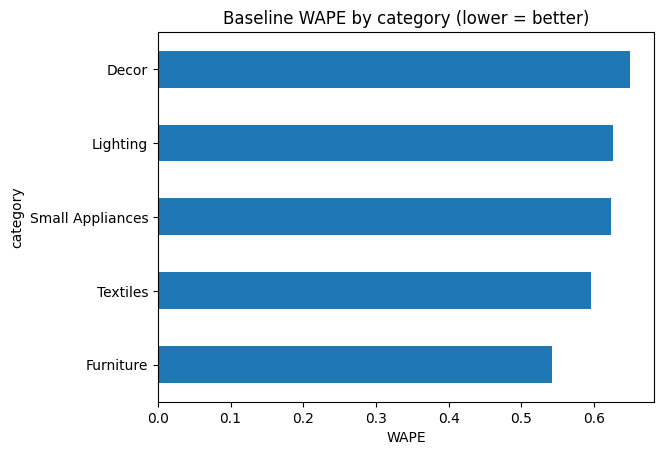

In [6]:
cat_wape.sort_values().plot.barh(title='Baseline WAPE by category (lower = better)')
plt.xlabel('WAPE')
plt.show()

## Conclusion
This is the bar. Any model trained in `03_model.ipynb` / `src/forecast.py` must beat this WAPE on a fair, rolling-origin backtest — not just on this single holdout window — before it's allowed to replace the baseline in production.